In [ ]:
## Conclusion

- Random Forest performed better than Linear Regression
- Feature "age" significantly impacts price
- Model shows good generalization with similar train/test scores

In [228]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("car data.csv")  
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [229]:
df = df.drop("Car_Name", axis=1)

df["age"] = 2020 - df["Year"]

df = df.drop("Year", axis=1)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


In [230]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]
X = pd.get_dummies(X, drop_first=True)

In [231]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [232]:
lr = LinearRegression()
lr.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [233]:
y_pred_lr = lr.predict(X_test)

print("🔹 Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

🔹 Linear Regression
MAE: 1.2163740193330421
MSE: 3.481349830511856
R2: 0.8488707839193137


In [234]:


rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n🔹 Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))


🔹 Random Forest
MAE: 0.6473748794317811
R2: 0.957431924915066


In [235]:
print("\n Overfitting Check because its rf")
print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))


 Overfitting Check because its rf
Train R2: 0.9773614481717683
Test R2: 0.957431924915066


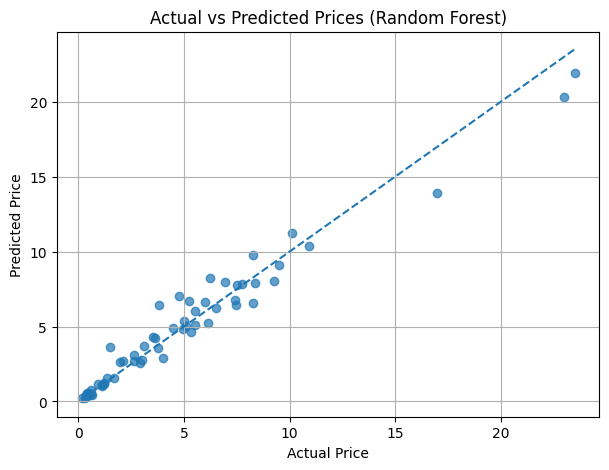

In [239]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_rf, alpha=0.7)


line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(line, line, linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.savefig("car_price_plot.png")
plt.grid(True)
plt.show()